# Fraud Detection in Decentralized Finance (DeFi) Transactions Using Machine Learning and Smart Contracts

## Module 1: Exploratory Data Analysis (EDA)

### Objective
The objective of this notebook is to understand the Ethereum Wallet Fraud Detection dataset through exploratory data analysis (EDA). This includes examining the dataset structure, identifying missing values and duplicates, analyzing the target variable, exploring feature distributions, and understanding relationships between features before building the machine learning model.


In [35]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Improve plot appearance
plt.style.use("ggplot")

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Initialize notebook state for static analysis; the loader replaces this value.
df_eda = pd.DataFrame()

In [36]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent
csv_path = project_root / "blockchain" / "dataset" / "transaction_dataset.csv"
df = pd.read_csv(csv_path)
df_eda = df.copy()

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (9841, 51)


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [37]:
# Display all column names

df.columns

Index(['Unnamed: 0', 'Index', 'Address', 'FLAG', 'Avg min between sent tnx',
       'Avg min between received tnx',
       'Time Diff between first and last (Mins)', 'Sent tnx', 'Received Tnx',
       'Number of Created Contracts', 'Unique Received From Addresses',
       'Unique Sent To Addresses', 'min value received', 'max value received ',
       'avg val received', 'min val sent', 'max val sent', 'avg val sent',
       'min value sent to contract', 'max val sent to contract',
       'avg value sent to contract',
       'total transactions (including tnx to create contract',
       'total Ether sent', 'total ether received',
       'total ether sent contracts', 'total ether balance',
       ' Total ERC20 tnxs', ' ERC20 total Ether received',
       ' ERC20 total ether sent', ' ERC20 total Ether sent contract',
       ' ERC20 uniq sent addr', ' ERC20 uniq rec addr',
       ' ERC20 uniq sent addr.1', ' ERC20 uniq rec contract addr',
       ' ERC20 avg time between sent tnx', ' ERC20 

In [38]:
# Number of rows and columns

print("Dataset Shape:", df.shape)   

Dataset Shape: (9841, 51)


DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   str    
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                     

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,9841.0,4.920000e+03,2.840996e+03,0.00,2460.000000,4.920000e+03,7380.000000,9.840000e+03
Index,9841.0,1.815050e+03,1.222622e+03,1.00,821.000000,1.641000e+03,2601.000000,4.729000e+03
FLAG,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
Avg min between sent tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
Avg min between received tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
Time Diff between first and last (Mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
Sent tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
Received Tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
Number of Created Contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
Unique Received From Addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03



MISSING VALUES


ERC20 most sent token type             2697
ERC20_most_rec_token_type               871
ERC20 total ether sent                  829
ERC20 total Ether received              829
ERC20 uniq sent addr                    829
ERC20 uniq rec addr                     829
ERC20 uniq sent addr.1                  829
ERC20 total Ether sent contract         829
Total ERC20 tnxs                        829
ERC20 avg time between sent tnx         829
ERC20 uniq rec contract addr            829
ERC20 avg time between rec tnx          829
ERC20 avg time between rec 2 tnx        829
ERC20 max val rec                       829
ERC20 avg val rec                       829
ERC20 avg time between contract tnx     829
ERC20 min val rec                       829
ERC20 max val sent                      829
ERC20 min val sent                      829
ERC20 avg val sent                      829
ERC20 min val sent contract             829
ERC20 avg val sent contract             829
ERC20 max val sent contract     


DUPLICATE ROWS
Duplicate Rows: 0

TARGET VARIABLE DISTRIBUTION (FLAG)
Count:
FLAG
0    7662
1    2179
Name: count, dtype: int64

Percentage:
FLAG
0    77.86
1    22.14
Name: proportion, dtype: float64


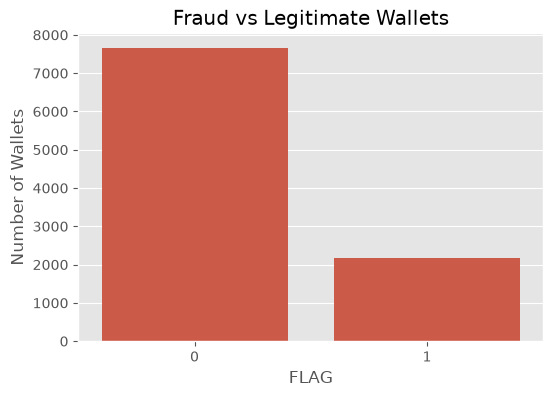

In [39]:
# ==========================================
# Basic Dataset Exploration
# ==========================================

# 1. Dataset Information
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

# 2. Statistical Summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
display(df.describe().T)

# 3. Missing Values
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) == 0:
    print("✅ No Missing Values Found")
else:
    display(missing)

# 4. Duplicate Rows
print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

# 5. Target Variable Distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION (FLAG)")
print("=" * 60)

print("Count:")
print(df["FLAG"].value_counts())

print("\nPercentage:")
print((df["FLAG"].value_counts(normalize=True) * 100).round(2))

# 6. Visualization of Target Variable
plt.figure(figsize=(6,4))

sns.countplot(x="FLAG", data=df)

plt.title("Fraud vs Legitimate Wallets")
plt.xlabel("FLAG")
plt.ylabel("Number of Wallets")

plt.show()

In [40]:
# ==========================================
# Missing Values, Duplicates and Target Analysis
# ==========================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

print("\n")

print("=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

print(df.duplicated().sum())

print("\n")

print("=" * 60)
print("TARGET VARIABLE")
print("=" * 60)

print(df["FLAG"].value_counts())

print("\nPercentage Distribution")

print((df["FLAG"].value_counts(normalize=True) * 100).round(2))

MISSING VALUES
ERC20 most sent token type             2697
ERC20_most_rec_token_type               871
ERC20 total ether sent                  829
ERC20 total Ether received              829
ERC20 uniq sent addr                    829
ERC20 uniq rec addr                     829
ERC20 uniq sent addr.1                  829
ERC20 total Ether sent contract         829
Total ERC20 tnxs                        829
ERC20 avg time between sent tnx         829
ERC20 uniq rec contract addr            829
ERC20 avg time between rec tnx          829
ERC20 avg time between rec 2 tnx        829
ERC20 max val rec                       829
ERC20 avg val rec                       829
ERC20 avg time between contract tnx     829
ERC20 min val rec                       829
ERC20 max val sent                      829
ERC20 min val sent                      829
ERC20 avg val sent                      829
ERC20 min val sent contract             829
ERC20 avg val sent contract             829
ERC20 max val sen

In [41]:
# ==========================================
# Missing Value Analysis
# ==========================================

missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage.round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
ERC20 most sent token type,2697,27.41
ERC20_most_rec_token_type,871,8.85
ERC20 total ether sent,829,8.42
ERC20 total Ether received,829,8.42
ERC20 uniq sent addr,829,8.42
ERC20 uniq rec addr,829,8.42
ERC20 uniq sent addr.1,829,8.42
ERC20 total Ether sent contract,829,8.42
Total ERC20 tnxs,829,8.42
ERC20 avg time between sent tnx,829,8.42


In [42]:
# ==========================================
# Check Whether Missing ERC20 Values
# Correspond to Zero ERC20 Activity
# ==========================================

erc20_activity = df[" Total ERC20 tnxs"]

print("Missing ERC20 transaction count:")
print(erc20_activity.isna().sum())

print("\nExisting ERC20 transaction count:")
print(erc20_activity.notna().sum())

print("\nExisting values equal to zero:")
print((erc20_activity == 0).sum())

print("\nExisting values greater than zero:")
print((erc20_activity > 0).sum())

Missing ERC20 transaction count:
829

Existing ERC20 transaction count:
9012

Existing values equal to zero:
4399

Existing values greater than zero:
4613


In [43]:
# ==========================================
# Feature Variance Analysis
# ==========================================

# Select numerical columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Calculate number of unique values
unique_counts = df[numeric_columns].nunique().sort_values()

print("=" * 60)
print("NUMERICAL FEATURES WITH FEWEST UNIQUE VALUES")
print("=" * 60)

display(unique_counts.head(15))

# Find constant features
constant_features = unique_counts[unique_counts <= 1]

print("\n" + "=" * 60)
print("CONSTANT FEATURES")
print("=" * 60)

if len(constant_features) == 0:
    print("No constant numerical features found.")
else:
    display(constant_features)

NUMERICAL FEATURES WITH FEWEST UNIQUE VALUES


 ERC20 avg time between contract tnx     1
 ERC20 min val sent contract             1
 ERC20 avg val sent contract             1
 ERC20 max val sent contract             1
 ERC20 avg time between rec tnx          1
 ERC20 avg time between rec 2 tnx        1
 ERC20 avg time between sent tnx         1
FLAG                                     2
min value sent to contract               3
total ether sent contracts               4
max val sent to contract                 4
avg value sent to contract               4
 ERC20 uniq sent addr.1                  4
Number of Created Contracts             20
 ERC20 total Ether sent contract        29
dtype: int64


CONSTANT FEATURES


ERC20 avg time between contract tnx    1
ERC20 min val sent contract            1
ERC20 avg val sent contract            1
ERC20 max val sent contract            1
ERC20 avg time between rec tnx         1
ERC20 avg time between rec 2 tnx       1
ERC20 avg time between sent tnx        1
dtype: int64

In [44]:
# ==========================================
# Feature Comparison: Fraud vs Legitimate
# ==========================================

# Separate the two classes
legitimate = df[df["FLAG"] == 0]
fraudulent = df[df["FLAG"] == 1]

print("=" * 60)
print("CLASS COUNTS")
print("=" * 60)

print(f"Legitimate wallets : {len(legitimate)}")
print(f"Fraudulent wallets : {len(fraudulent)}")

# Select numerical features
numeric_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

# Remove target from analysis
numeric_features = numeric_features.drop("FLAG")

# Calculate mean for each class
comparison = pd.DataFrame({
    "Legitimate Mean": legitimate[numeric_features].mean(),
    "Fraud Mean": fraudulent[numeric_features].mean()
})

# Calculate percentage difference
comparison["Difference (%)"] = (
    (comparison["Fraud Mean"] - comparison["Legitimate Mean"])
    / comparison["Legitimate Mean"].replace(0, np.nan)
) * 100

# Sort by absolute difference
comparison["Absolute Difference (%)"] = comparison["Difference (%)"].abs()

comparison = comparison.sort_values(
    "Absolute Difference (%)",
    ascending=False
)

display(comparison.head(20))

CLASS COUNTS
Legitimate wallets : 7662
Fraudulent wallets : 2179


,Legitimate Mean,Fraud Mean,Difference (%),Absolute Difference (%)
ERC20 avg val sent,1.010530e+05,4.160523e+07,41071.677867,41071.677867
ERC20 min val sent,5.248362e+02,7.540068e+04,14266.516930,14266.516930
ERC20 max val sent,6.359648e+05,8.341266e+07,13015.923775,13015.923775
ERC20 total ether sent,1.600111e+06,8.349837e+07,5118.286585,5118.286585
ERC20 total Ether sent contract,7.617622e+01,3.082384e+02,304.638648,304.638648
ERC20 avg val rec,3.637878e+06,8.366339e+06,129.978514,129.978514
ERC20 min val rec,4.065076e+02,9.345913e+02,129.907450,129.907450
Unnamed: 0,3.830500e+03,8.751000e+03,128.455815,128.455815
max val sent to contract,9.922866e-06,0.000000e+00,-100.000000,100.000000
avg value sent to contract,6.919081e-06,0.000000e+00,-100.000000,100.000000


In [45]:
# ==========================================
# Create Clean EDA Dataset
# ==========================================

# Keep the original dataset untouched
df_eda = df.copy()

# Identifier columns - not useful as ML features
identifier_columns = [
    "Unnamed: 0",
    "Index",
    "Address"
]

# Remove identifiers
df_eda = df_eda.drop(columns=identifier_columns)

print("=" * 60)
print("ORIGINAL DATASET")
print("=" * 60)
print("Shape:", df.shape)

print("\n" + "=" * 60)
print("EDA DATASET")
print("=" * 60)
print("Shape:", df_eda.shape)

print("\nRemoved columns:")
print(identifier_columns)

ORIGINAL DATASET
Shape: (9841, 51)

EDA DATASET
Shape: (9841, 48)

Removed columns:
['Unnamed: 0', 'Index', 'Address']


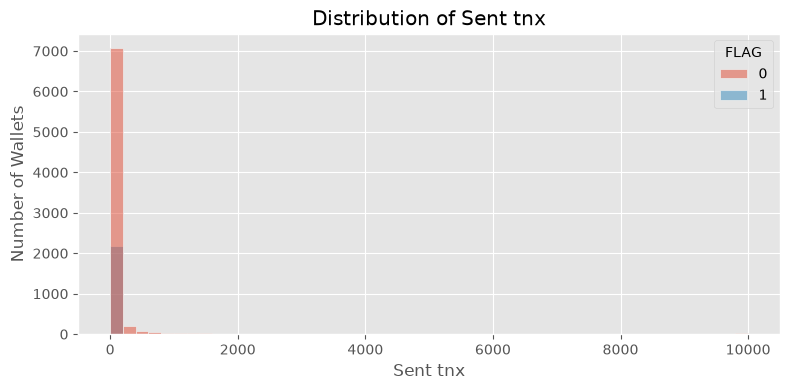

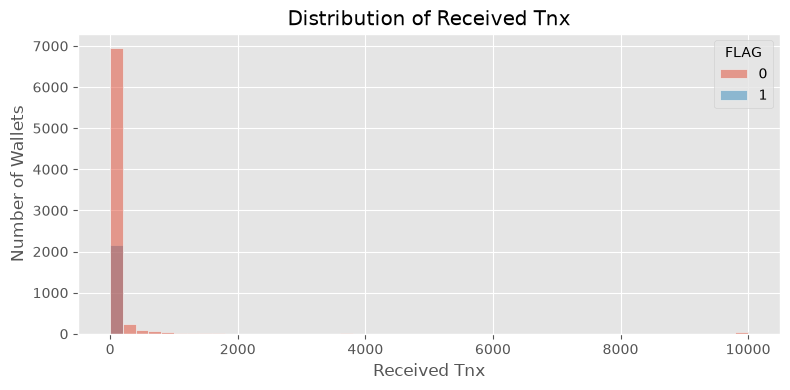

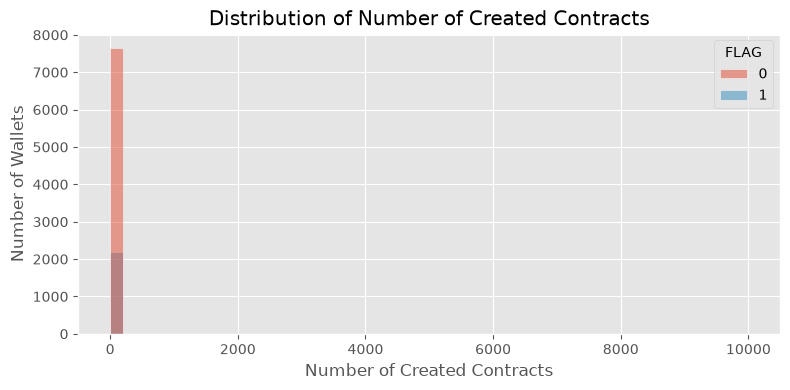

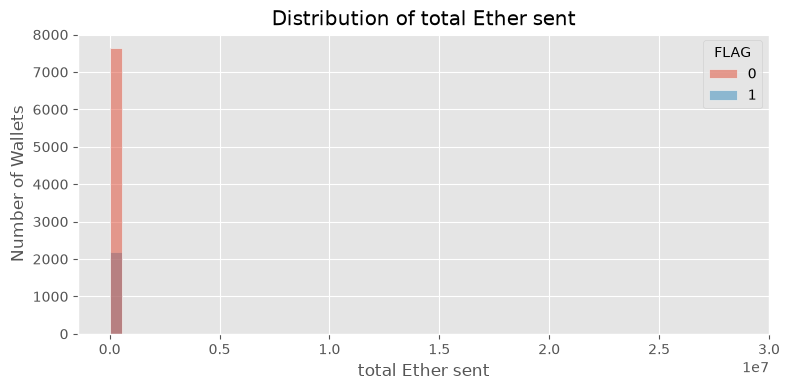

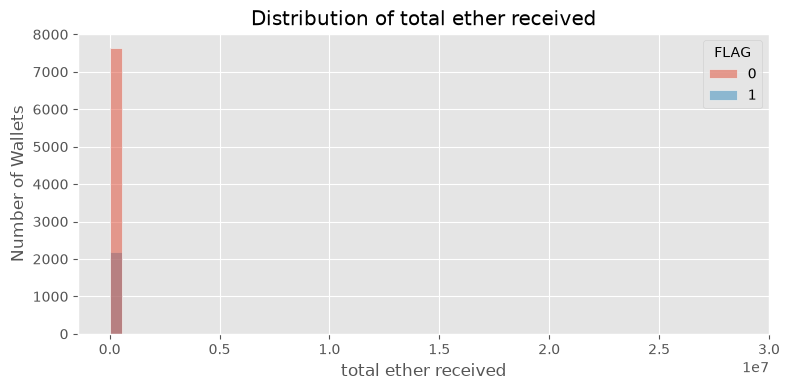

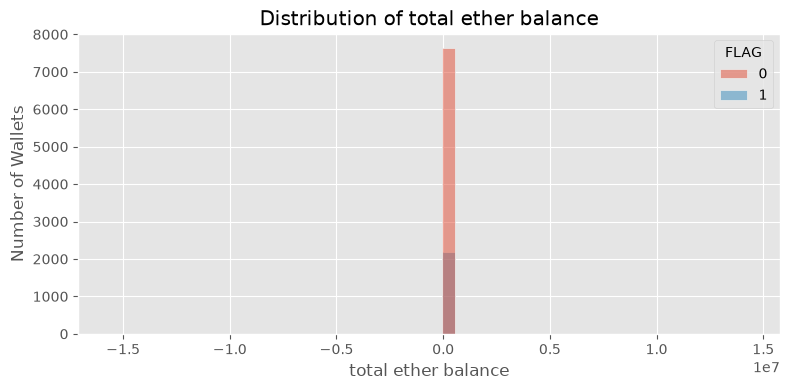

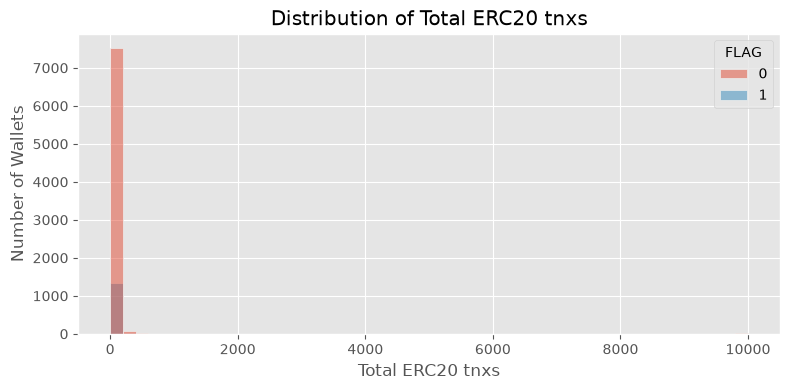

In [46]:
# ==========================================
# Distribution Analysis
# ==========================================

# Keep this analysis cell independently runnable.
df_eda = df.copy()
df_eda.columns = df_eda.columns.str.strip()

features_to_plot = [
    "Sent tnx",
    "Received Tnx",
    "Number of Created Contracts",
    "total Ether sent",
    "total ether received",
    "total ether balance",
    "Total ERC20 tnxs"
]

for feature in features_to_plot:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df_eda,
        x=feature,
        hue="FLAG",
        bins=50
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Wallets")

    plt.tight_layout()
    plt.show()

In [47]:
# ============================================================
# PHASE 2: DATA PREPROCESSING
# STEP 1: REMOVE CONSTANT FEATURES
# ============================================================

# Remove leading/trailing spaces from column names
df_eda.columns = df_eda.columns.str.strip()

print("Features before removal:", df_eda.shape[1])

# Automatically find columns having only one unique value
constant_features = [
    column for column in df_eda.columns
    if df_eda[column].nunique(dropna=False) <= 1
]

print("\nConstant features found:")
for feature in constant_features:
    print("-", feature)

# Remove constant features
df_eda = df_eda.drop(columns=constant_features)

print("\nFeatures after removal:", df_eda.shape[1])

Features before removal: 51

Constant features found:

Features after removal: 51


In [48]:
# Show all currently defined variables
%whos DataFrame

Variable           Type         Data/Info
-----------------------------------------
X                  DataFrame    Shape: (9841, 39)
X_test             DataFrame    Shape: (1969, 39)
X_train            DataFrame    Shape: (7872, 39)
comparison         DataFrame    Shape: (47, 4)
df                 DataFrame    Shape: (9841, 51)
df_eda             DataFrame    Shape: (9841, 51)
df_model           DataFrame    Shape: (9841, 40)
fraud_rate         DataFrame    Shape: (2, 4)
fraud_sample       DataFrame    Shape: (1, 39)
fraudulent         DataFrame    Shape: (2179, 51)
legitimate         DataFrame    Shape: (7662, 51)
missing_summary    DataFrame    Shape: (25, 2)
shap_df            DataFrame    Shape: (39, 4)
shap_explanation   DataFrame    Shape: (39, 3)
test_samples       DataFrame    Shape: (5, 39)
wallet_features    DataFrame    Shape: (1, 39)


In [49]:
# ============================================================
# STEP 2: ANALYZE ERC20 MISSING-VALUE PATTERN
# ============================================================

# Keep this analysis cell independently runnable.
df_eda = df.copy()
df_eda.columns = df_eda.columns.str.strip()

# Count missing values in every column
missing_counts = df_eda.isnull().sum()

# Show columns with missing values
erc20_missing = missing_counts[missing_counts > 0].sort_values(
    ascending=False
)

print("=" * 60)
print("MISSING VALUE SUMMARY")
print("=" * 60)

display(erc20_missing)

# Check how many rows have missing values in the ERC20 transaction column
print("\n" + "=" * 60)
print("ERC20 MISSING PATTERN")
print("=" * 60)

erc20_tnx_col = "Total ERC20 tnxs"

print(
    "Rows with ERC20 transaction data:",
    df_eda[erc20_tnx_col].notna().sum()
)

print(
    "Rows without ERC20 transaction data:",
    df_eda[erc20_tnx_col].isna().sum()
)

# Create a flag indicating whether ERC20 data is missing
df_eda["ERC20_data_missing"] = df_eda[erc20_tnx_col].isna().astype(int)

print("\nERC20 data missing flag:")
print(df_eda["ERC20_data_missing"].value_counts())

# Compare fraud rate between the two groups
print("\n" + "=" * 60)
print("FRAUD RATE BY ERC20 DATA AVAILABILITY")
print("=" * 60)

fraud_rate = (
    df_eda.groupby("ERC20_data_missing")["FLAG"]
    .agg(["count", "sum", "mean"])
)

fraud_rate["fraud_percentage"] = fraud_rate["mean"] * 100

display(fraud_rate)

MISSING VALUE SUMMARY


ERC20 most sent token type             2697
ERC20_most_rec_token_type               871
ERC20 total ether sent                  829
ERC20 total Ether received              829
ERC20 uniq sent addr                    829
ERC20 uniq rec addr                     829
ERC20 uniq sent addr.1                  829
ERC20 total Ether sent contract         829
Total ERC20 tnxs                        829
ERC20 avg time between sent tnx         829
ERC20 uniq rec contract addr            829
ERC20 avg time between rec tnx          829
ERC20 avg time between rec 2 tnx        829
ERC20 max val rec                       829
ERC20 avg val rec                       829
ERC20 avg time between contract tnx     829
ERC20 min val rec                       829
ERC20 max val sent                      829
ERC20 min val sent                      829
ERC20 avg val sent                      829
ERC20 min val sent contract             829
ERC20 avg val sent contract             829
ERC20 max val sent contract     


ERC20 MISSING PATTERN
Rows with ERC20 transaction data: 9012
Rows without ERC20 transaction data: 829

ERC20 data missing flag:
ERC20_data_missing
0    9012
1     829
Name: count, dtype: int64

FRAUD RATE BY ERC20 DATA AVAILABILITY


,count,sum,mean,fraud_percentage
ERC20_data_missing,,,,
0,9012,1350,0.1498,14.980027
1,829,829,1.0000,100.000000


In [50]:
# ============================================================
# STEP 2: ANALYZE ERC20 MISSING-VALUE PATTERN
# ============================================================

# Keep this analysis cell independently runnable.
df_eda = df.copy()
df_eda.columns = df_eda.columns.str.strip()

# Count missing values in every column
missing_counts = df_eda.isnull().sum()

# Show columns with missing values
erc20_missing = missing_counts[missing_counts > 0].sort_values(
    ascending=False
)

print("=" * 60)
print("MISSING VALUE SUMMARY")
print("=" * 60)

display(erc20_missing)

# Check how many rows have missing values in the ERC20 transaction column
print("\n" + "=" * 60)
print("ERC20 MISSING PATTERN")
print("=" * 60)

erc20_tnx_col = "Total ERC20 tnxs"

print(
    "Rows with ERC20 transaction data:",
    df_eda[erc20_tnx_col].notna().sum()
)

print(
    "Rows without ERC20 transaction data:",
    df_eda[erc20_tnx_col].isna().sum()
)

# Create a flag indicating whether ERC20 data is missing
df_eda["ERC20_data_missing"] = df_eda[erc20_tnx_col].isna().astype(int)

print("\nERC20 data missing flag:")
print(df_eda["ERC20_data_missing"].value_counts())

# Compare fraud rate between the two groups
print("\n" + "=" * 60)
print("FRAUD RATE BY ERC20 DATA AVAILABILITY")
print("=" * 60)

fraud_rate = (
    df_eda.groupby("ERC20_data_missing")["FLAG"]
    .agg(["count", "sum", "mean"])
)

fraud_rate["fraud_percentage"] = fraud_rate["mean"] * 100

display(fraud_rate)

MISSING VALUE SUMMARY


ERC20 most sent token type             2697
ERC20_most_rec_token_type               871
ERC20 total ether sent                  829
ERC20 total Ether received              829
ERC20 uniq sent addr                    829
ERC20 uniq rec addr                     829
ERC20 uniq sent addr.1                  829
ERC20 total Ether sent contract         829
Total ERC20 tnxs                        829
ERC20 avg time between sent tnx         829
ERC20 uniq rec contract addr            829
ERC20 avg time between rec tnx          829
ERC20 avg time between rec 2 tnx        829
ERC20 max val rec                       829
ERC20 avg val rec                       829
ERC20 avg time between contract tnx     829
ERC20 min val rec                       829
ERC20 max val sent                      829
ERC20 min val sent                      829
ERC20 avg val sent                      829
ERC20 min val sent contract             829
ERC20 avg val sent contract             829
ERC20 max val sent contract     


ERC20 MISSING PATTERN
Rows with ERC20 transaction data: 9012
Rows without ERC20 transaction data: 829

ERC20 data missing flag:
ERC20_data_missing
0    9012
1     829
Name: count, dtype: int64

FRAUD RATE BY ERC20 DATA AVAILABILITY


,count,sum,mean,fraud_percentage
ERC20_data_missing,,,,
0,9012,1350,0.1498,14.980027
1,829,829,1.0000,100.000000


In [51]:
# ============================================================
# STEP 3: ANALYZE ERC20 TOKEN TYPE FEATURES
# ============================================================

categorical_features = [
    "ERC20 most sent token type",
    "ERC20_most_rec_token_type"
]

for col in categorical_features:

    print("\n" + "=" * 60)
    print("COLUMN:", col)
    print("=" * 60)

    print("Data type:", df_eda[col].dtype)
    print("Unique values:", df_eda[col].nunique(dropna=False))
    print("Missing values:", df_eda[col].isna().sum())

    print("\nMost common values:")
    display(
        df_eda[col]
        .value_counts(dropna=False)
        .head(15)
    )


COLUMN: ERC20 most sent token type
Data type: str
Unique values: 305
Missing values: 2697

Most common values:


ERC20 most sent token type
0                                4399
NaN                              2697
                                 1191
EOS                               138
OmiseGO                           137
Golem                             130
blockwell.ai KYC Casper Token     128
StatusNetwork                      61
BAT                                38
Qtum                               34
Bancor                             32
Reputation                         26
Tronix                             26
TenXPay                            25
Crypto.com                         20
Name: count, dtype: int64


COLUMN: ERC20_most_rec_token_type
Data type: str
Unique values: 467
Missing values: 871

Most common values:


ERC20_most_rec_token_type
0                                4399
OmiseGO                           873
NaN                               871
Blockwell say NOTSAFU             779
DATAcoin                          358
Livepeer Token                    207
EOS                               161
XENON                             145
Golem                             126
GSENetwork                         80
Tronix                             76
blockwell.ai KYC Casper Token      65
Promodl                            52
VIU                                50
INS Promo                          44
Name: count, dtype: int64

In [52]:
# ============================================================
# MODEL PREPROCESSING: CREATE A REPRODUCIBLE FEATURE TABLE
# ============================================================

# Always restart from the raw dataframe so this cell can be run repeatedly.
df_model = df.copy()
df_model.columns = df_model.columns.str.strip()

target_column = "FLAG"
identifier_columns = ["Unnamed: 0", "Index", "Address"]
token_name_columns = [
    "ERC20 most sent token type",
    "ERC20_most_rec_token_type",
]

# Retain ERC20 availability as an explicit signal before numerical imputation.
df_model["ERC20_data_missing"] = df_model["Total ERC20 tnxs"].isna().astype(int)

# Remove non-predictive identifiers and high-cardinality raw token labels.
df_model = df_model.drop(columns=identifier_columns + token_name_columns)

# Remove numeric features with no variation.
constant_features = [
    column for column in df_model.columns
    if column != target_column and df_model[column].nunique(dropna=True) <= 1
]
df_model = df_model.drop(columns=constant_features)

# The imputer is fitted on training data in the next cell to prevent validation leakage.
X = df_model.drop(columns=target_column)
y = df_model[target_column]

print("Model table shape:", df_model.shape)
print("Predictor count:", X.shape[1])
print("Removed constant features:", constant_features)
print("Rows with missing ERC20 data:", int(X["ERC20_data_missing"].sum()))
print("Remaining missing numeric values:", int(X.isna().sum().sum()))

Model table shape: (9841, 40)
Predictor count: 39
Removed constant features: ['ERC20 avg time between sent tnx', 'ERC20 avg time between rec tnx', 'ERC20 avg time between rec 2 tnx', 'ERC20 avg time between contract tnx', 'ERC20 min val sent contract', 'ERC20 max val sent contract', 'ERC20 avg val sent contract']
Rows with missing ERC20 data: 829
Remaining missing numeric values: 13264


In [53]:
# ============================================================
# MODULE 1 — STEP 2
# TRAIN / TEST SPLIT
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# X and y were created by the reproducible preprocessing cell above.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Fit preprocessing on training data only, then apply it to both partitions.
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(
    imputer.fit_transform(X_train), columns=X.columns, index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test), columns=X.columns, index=X_test.index
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples :", X_train.shape[0])
print("Testing samples  :", X_test.shape[0])

print("\nTraining features:", X_train.shape[1])
print("Testing features :", X_test.shape[1])

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTraining fraud percentage:",
      round(y_train.mean() * 100, 2), "%")

print("Testing fraud percentage:",
      round(y_test.mean() * 100, 2), "%")

TRAIN / TEST SPLIT
Training samples : 7872
Testing samples  : 1969

Training features: 39
Testing features : 39

Training class distribution:
FLAG
0    6129
1    1743
Name: count, dtype: int64

Testing class distribution:
FLAG
0    1533
1     436
Name: count, dtype: int64

Training fraud percentage: 22.14 %
Testing fraud percentage: 22.14 %


In [54]:
from xgboost import XGBClassifier

# Balance the loss so the minority fraud class receives proportionate weight.
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric=["logloss", "aucpr"]
)

print("=" * 60)
print("XGBOOST MODEL TRAINING")
print("=" * 60)
print(f"Training fraud samples: {positive_count}")
print(f"Training legitimate samples: {negative_count}")
print(f"Fraud class weight: {scale_pos_weight:.2f}")

xgb_model.fit(X_train, y_train)

print("\nXGBoost model training completed successfully!")
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

XGBOOST MODEL TRAINING
Training fraud samples: 1743
Training legitimate samples: 6129
Fraud class weight: 3.52



XGBoost model training completed successfully!


In [55]:
# ============================================================
# XGBOOST PREDICTIONS
# ============================================================

y_pred = xgb_model.predict(X_test)

# Probability of class 1 (Fraud)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("XGBOOST PREDICTIONS")
print("=" * 60)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))
print("Number of probabilities:", len(y_pred_proba))

XGBOOST PREDICTIONS
Predictions generated successfully!
Number of predictions: 1969
Number of probabilities: 1969


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# XGBOOST MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("XGBOOST MODEL EVALUATION")
print("=" * 60)

print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"]
))

XGBOOST MODEL EVALUATION

Accuracy  : 0.9873
Precision : 0.9768
Recall    : 0.9656
F1-Score  : 0.9712
ROC-AUC   : 0.9983

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      1533
       Fraud       0.98      0.97      0.97       436

    accuracy                           0.99      1969
   macro avg       0.98      0.98      0.98      1969
weighted avg       0.99      0.99      0.99      1969



CONFUSION MATRIX
[[1523   10]
 [  15  421]]

True Negatives  (TN): 1523
False Positives (FP): 10
False Negatives (FN): 15
True Positives  (TP): 421


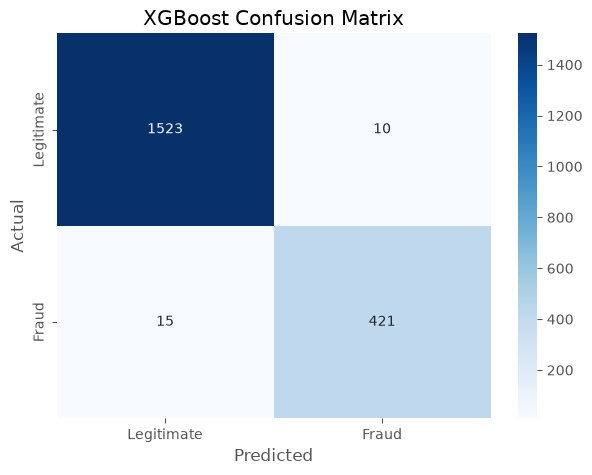

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)

print("\nTrue Negatives  (TN):", cm[0, 0])
print("False Positives (FP):", cm[0, 1])
print("False Negatives (FN):", cm[1, 0])
print("True Positives  (TP):", cm[1, 1])

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [58]:
import joblib
import os

# Create models directory
os.makedirs("models", exist_ok=True)

# Save trained XGBoost model
model_path = "models/fraud_model.pkl"

joblib.dump(xgb_model, model_path)

print("=" * 60)
print("MODEL SAVING")
print("=" * 60)
print(f"Model saved successfully!")
print(f"Path: {model_path}")

MODEL SAVING
Model saved successfully!
Path: models/fraud_model.pkl


In [59]:
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "models/feature_columns.pkl")

print(f"Number of features saved: {len(feature_columns)}")

Number of features saved: 39


In [60]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Save XGBoost model
joblib.dump(xgb_model, "models/fraud_model.pkl")

# Save feature names/order and the fitted preprocessing artifact.
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, "models/feature_columns.pkl")
joblib.dump(imputer, "models/median_imputer.pkl")

print("=" * 60)
print("MODEL ARTIFACTS")
print("=" * 60)
print("Model saved          : models/fraud_model.pkl")
print("Feature list saved   : models/feature_columns.pkl")
print("Imputer saved        : models/median_imputer.pkl")
print("Number of features   :", len(feature_columns))

MODEL ARTIFACTS
Model saved          : models/fraud_model.pkl
Feature list saved   : models/feature_columns.pkl
Imputer saved        : models/median_imputer.pkl
Number of features   : 39


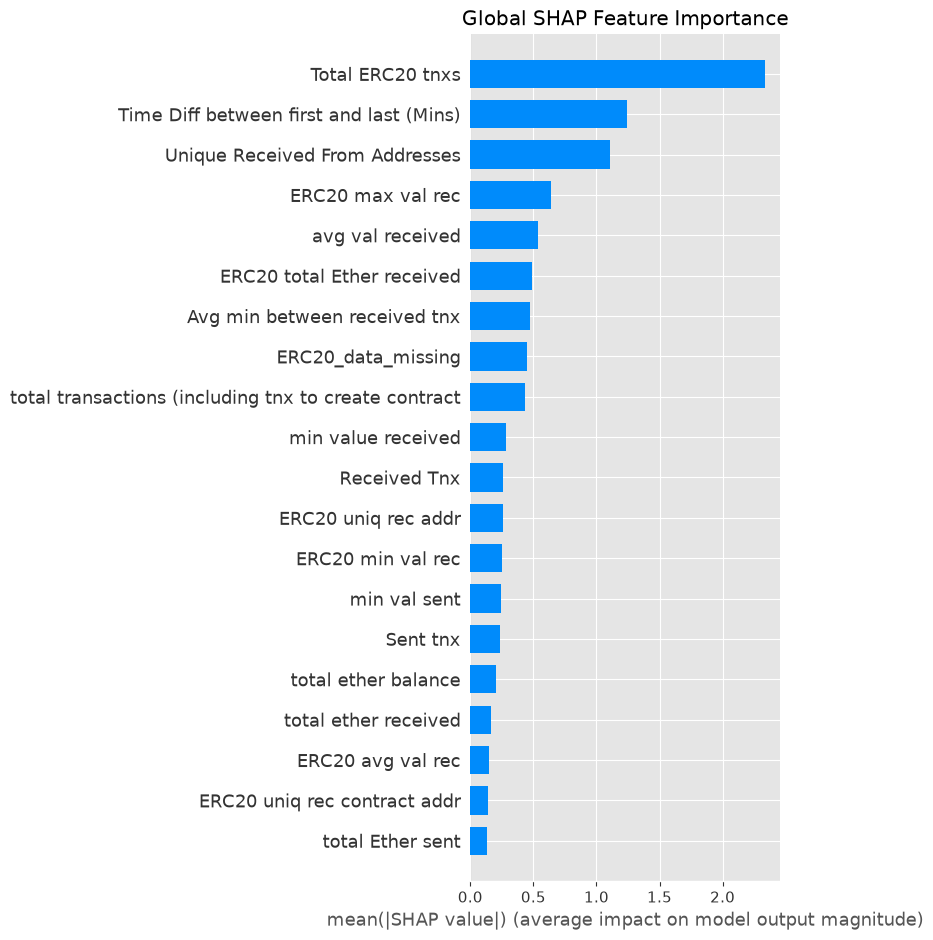

In [61]:
# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [62]:
# Select one correctly detected fraudulent wallet
fraud_indices = np.flatnonzero(y_test.to_numpy() == 1)
idx = fraud_indices[0]

wallet_features = X_test.iloc[[idx]]

prediction = xgb_model.predict(wallet_features)[0]
probability = xgb_model.predict_proba(wallet_features)[0][1]

print("=" * 60)
print("INDIVIDUAL WALLET PREDICTION")
print("=" * 60)

print("Prediction:", "FRAUD" if prediction == 1 else "LEGITIMATE")
print(f"Fraud Probability: {probability:.4f}")
print(f"Fraud Probability: {probability * 100:.2f}%")

INDIVIDUAL WALLET PREDICTION
Prediction: FRAUD
Fraud Probability: 0.9997
Fraud Probability: 99.97%


In [63]:
# ============================================================
# INDIVIDUAL SHAP EXPLANATION
# ============================================================

wallet_shap = shap_values[idx]

# Create feature contribution table
shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": wallet_shap,
    "Feature Value": X_test.iloc[idx].values
})

# Sort by absolute SHAP contribution
shap_df["Absolute SHAP"] = shap_df["SHAP Value"].abs()

shap_df = shap_df.sort_values(
    by="Absolute SHAP",
    ascending=False
)

print("=" * 60)
print("TOP SHAP FEATURES FOR SELECTED WALLET")
print("=" * 60)

print(shap_df.head(10).to_string(index=False))

TOP SHAP FEATURES FOR SELECTED WALLET
                                             Feature  SHAP Value  Feature Value  Absolute SHAP
                                  ERC20_data_missing    2.874357   1.000000e+00       2.874357
                                    Total ERC20 tnxs    1.648928   1.000000e+00       1.648928
             Time Diff between first and last (Mins)    1.236290   0.000000e+00       1.236290
                      Unique Received From Addresses   -1.086031   0.000000e+00       1.086031
                          ERC20 total Ether received    1.046973   9.110000e-13       1.046973
                                  min value received    0.566424   0.000000e+00       0.566424
                                    avg val received    0.510566   0.000000e+00       0.510566
total transactions (including tnx to create contract    0.481631   0.000000e+00       0.481631
                                   ERC20 max val rec   -0.355254   0.000000e+00       0.355254
            

In [64]:
# ============================================================
# RISK SCORING ENGINE
# ============================================================

def calculate_risk_score(fraud_probability):
    """
    Convert fraud probability into a risk score from 0 to 100.
    """
    return round(fraud_probability * 100, 2)


def get_risk_level(risk_score):
    """
    Convert risk score into a risk category.
    """
    if risk_score <= 30:
        return "LOW"
    elif risk_score <= 70:
        return "MEDIUM"
    else:
        return "HIGH"


def get_recommendation(risk_level):
    """
    Generate an action recommendation based on risk level.
    """
    if risk_level == "LOW":
        return "PROCEED"
    elif risk_level == "MEDIUM":
        return "PROCEED WITH CAUTION"
    else:
        return "AVOID TRANSACTION"


print("Risk scoring functions created successfully!")
# ============================================================
# FRAUD RISK ASSESSMENT
# ============================================================

risk_score = calculate_risk_score(probability)
risk_level = get_risk_level(risk_score)
recommendation = get_recommendation(risk_level)

print("=" * 60)
print("FRAUD RISK ASSESSMENT")
print("=" * 60)

print(f"Fraud Probability : {probability * 100:.2f}%")
print(f"Risk Score        : {risk_score}/100")
print(f"Risk Level        : {risk_level}")
print(f"Recommendation    : {recommendation}")

Risk scoring functions created successfully!
FRAUD RISK ASSESSMENT
Fraud Probability : 99.97%
Risk Score        : 99.97000122070312/100
Risk Level        : HIGH
Recommendation    : AVOID TRANSACTION


In [65]:
# Check what variables are currently available

print("Available variables:")
print([x for x in globals().keys() if not x.startswith("_")])

Available variables:
['In', 'Out', 'get_ipython', 'exit', 'quit', 'open', 'pd', 'np', 'plt', 'sns', 'warnings', 'df_eda', 'Path', 'project_root', 'csv_path', 'df', 'missing', 'duplicates', 'missing_percentage', 'missing_summary', 'erc20_activity', 'numeric_columns', 'unique_counts', 'constant_features', 'legitimate', 'fraudulent', 'numeric_features', 'comparison', 'identifier_columns', 'features_to_plot', 'feature', 'missing_counts', 'erc20_missing', 'erc20_tnx_col', 'fraud_rate', 'categorical_features', 'col', 'df_model', 'target_column', 'token_name_columns', 'X', 'y', 'SimpleImputer', 'train_test_split', 'X_train', 'X_test', 'y_train', 'y_test', 'imputer', 'XGBClassifier', 'xgb_model', 'y_pred', 'y_pred_proba', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score', 'classification_report', 'confusion_matrix', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'cm', 'joblib', 'os', 'model_path', 'feature_columns', 'shap', 'explainer', 'shap_values', 'fraud

In [66]:
# ============================================================
# REUSABLE FRAUD PREDICTION FUNCTION
# ============================================================

import joblib

model_dir = Path("models")
saved_model = joblib.load(model_dir / "fraud_model.pkl")
saved_features = joblib.load(model_dir / "feature_columns.pkl")
saved_imputer = joblib.load(model_dir / "median_imputer.pkl")

def predict_fraud_risk(wallet_features, threshold=0.50):
    """Return a fraud assessment for one wallet feature record."""
    if not 0 < threshold < 1:
        raise ValueError("threshold must be between 0 and 1")

    if isinstance(wallet_features, dict):
        wallet_frame = pd.DataFrame([wallet_features])
    elif isinstance(wallet_features, pd.DataFrame) and len(wallet_features) == 1:
        wallet_frame = wallet_features.copy()
    else:
        raise TypeError("wallet_features must be a dict or a one-row DataFrame")

    wallet_frame.columns = wallet_frame.columns.str.strip()
    if "ERC20_data_missing" not in wallet_frame.columns:
        if "Total ERC20 tnxs" not in wallet_frame.columns:
            raise ValueError("Provide Total ERC20 tnxs or ERC20_data_missing")
        wallet_frame["ERC20_data_missing"] = (
            wallet_frame["Total ERC20 tnxs"].isna().astype(int)
        )

    missing_features = [
        feature for feature in saved_features if feature not in wallet_frame.columns
    ]
    if missing_features:
        raise ValueError(f"Missing required features: {missing_features}")

    model_input = wallet_frame.reindex(columns=saved_features)
    model_input = pd.DataFrame(
        saved_imputer.transform(model_input), columns=saved_features
    )
    fraud_probability = float(saved_model.predict_proba(model_input)[0, 1])
    risk_score = calculate_risk_score(fraud_probability)
    risk_level = get_risk_level(risk_score)

    return {
        "prediction": "FRAUD" if fraud_probability >= threshold else "LEGITIMATE",
        "fraud_probability": round(fraud_probability, 4),
        "risk_score": risk_score,
        "risk_level": risk_level,
        "recommendation": get_recommendation(risk_level),
    }

# Example: score one processed wallet from the test partition.
example_prediction = predict_fraud_risk(X_test.iloc[[0]])
print(example_prediction)

{'prediction': 'FRAUD', 'fraud_probability': 0.9997, 'risk_score': 99.97, 'risk_level': 'HIGH', 'recommendation': 'AVOID TRANSACTION'}


In [67]:
# ============================================================
# THRESHOLD ANALYSIS AND CLEAR PREDICTION EXAMPLES
# ============================================================

# Compare candidate operating thresholds before deploying the model.
threshold_results = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    threshold_predictions = (y_pred_proba >= threshold).astype(int)
    threshold_cm = confusion_matrix(y_test, threshold_predictions)
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_predictions),
        "Recall": recall_score(y_test, threshold_predictions),
        "F1-Score": f1_score(y_test, threshold_predictions),
        "False Positives": threshold_cm[0, 1],
        "False Negatives": threshold_cm[1, 0],
    })

threshold_comparison = pd.DataFrame(threshold_results)
display(threshold_comparison.round(4))

# Use 0.50 unless the threshold comparison supports a different policy choice.
operating_threshold = 0.50

# Get fraud probabilities for the entire test set
test_probabilities = xgb_model.predict_proba(X_test)[:, 1]

# Find:
# 1. Fraud sample with highest predicted probability
# 2. Legitimate sample with lowest predicted probability

fraud_test_indices = np.where(y_test.values == 1)[0]
legit_test_indices = np.where(y_test.values == 0)[0]

best_fraud_idx = fraud_test_indices[
    np.argmax(test_probabilities[fraud_test_indices])
]

best_legit_idx = legit_test_indices[
    np.argmin(test_probabilities[legit_test_indices])
]

# ------------------------------------------------------------
# Display Fraud Example
# ------------------------------------------------------------

fraud_probability = test_probabilities[best_fraud_idx]

print("=" * 60)
print("🔴 FRAUD PREDICTION DEMO")
print("=" * 60)

print(f"Actual Label      : FRAUD")
print(f"Predicted Label   : {'FRAUD' if fraud_probability >= 0.5 else 'LEGITIMATE'}")
print(f"Fraud Probability : {fraud_probability * 100:.2f}%")

fraud_score = calculate_risk_score(fraud_probability)
fraud_level = get_risk_level(fraud_score)
fraud_recommendation = get_recommendation(fraud_level)

print(f"Risk Score        : {fraud_score:.2f} / 100")
print(f"Risk Level        : {fraud_level}")
print(f"Recommendation    : {fraud_recommendation}")


# ------------------------------------------------------------
# Display Legitimate Example
# ------------------------------------------------------------

legit_probability = test_probabilities[best_legit_idx]

print("\n" + "=" * 60)
print("🟢 LEGITIMATE PREDICTION DEMO")
print("=" * 60)

print(f"Actual Label      : LEGITIMATE")
print(f"Predicted Label   : {'FRAUD' if legit_probability >= 0.5 else 'LEGITIMATE'}")
print(f"Fraud Probability : {legit_probability * 100:.2f}%")

legit_score = calculate_risk_score(legit_probability)
legit_level = get_risk_level(legit_score)
legit_recommendation = get_recommendation(legit_level)

print(f"Risk Score        : {legit_score:.2f} / 100")
print(f"Risk Level        : {legit_level}")
print(f"Recommendation    : {legit_recommendation}")

🔴 FRAUD PREDICTION DEMO
Actual Label      : FRAUD
Predicted Label   : FRAUD
Fraud Probability : 100.00%
Risk Score        : 100.00 / 100
Risk Level        : HIGH
Recommendation    : AVOID TRANSACTION

🟢 LEGITIMATE PREDICTION DEMO
Actual Label      : LEGITIMATE
Predicted Label   : LEGITIMATE
Fraud Probability : 0.00%
Risk Score        : 0.00 / 100
Risk Level        : LOW
Recommendation    : PROCEED


In [68]:
# ============================================================
# SHAP EXPLANATION FOR FRAUD PREDICTION
# ============================================================

# Get the fraud sample
fraud_sample = X_test.iloc[[best_fraud_idx]]

# Calculate SHAP values for this sample
fraud_shap_values = explainer(fraud_sample)

# Convert SHAP values to a DataFrame
shap_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Value": fraud_shap_values.values[0]
})

# Calculate absolute SHAP values
shap_explanation["Absolute SHAP"] = (
    shap_explanation["SHAP Value"].abs()
)

# Sort by importance
shap_explanation = shap_explanation.sort_values(
    "Absolute SHAP",
    ascending=False
)

# Display top 10 features
print("=" * 70)
print("🔍 SHAP EXPLANATION — WHY WAS THIS WALLET FLAGGED?")
print("=" * 70)

print("\nTop features influencing the fraud prediction:\n")

print(
    shap_explanation[
        ["Feature", "SHAP Value"]
    ].head(10).to_string(index=False)
)

🔍 SHAP EXPLANATION — WHY WAS THIS WALLET FLAGGED?

Top features influencing the fraud prediction:

                                             Feature  SHAP Value
                                  ERC20_data_missing    2.259978
                      Unique Received From Addresses    1.567513
                                    Total ERC20 tnxs    1.468895
             Time Diff between first and last (Mins)    1.049542
                          ERC20 total Ether received    0.999773
                        Avg min between received tnx    0.542054
                                        min val sent    0.538623
                                   ERC20 max val rec   -0.450012
total transactions (including tnx to create contract    0.410188
                                  min value received    0.404631
